# Day 36: Machine Learning Boosting

---

## Objectives:

- Understand the concept of **Boosting** in Machine Learning.
- Learn about **AdaBoost** and **Gradient Boosting** algorithms.
- Explore scenarios where Boosting is beneficial.
- Apply Boosting techniques on a real-world business dataset.
- Evaluate and compare the performance of AdaBoost and Gradient Boosting models.
- **Enhance insights with robust visualizations before and after applying ML boosting.**

---

## 1. Introduction to Boosting

### 1.1 What is Boosting?

**Boosting** is an ensemble technique that combines multiple weak learners to create a strong learner. It sequentially trains models, each attempting to correct the errors of its predecessor, thereby improving overall performance.

### 1.2 When and Where to Use Boosting?

Boosting is particularly useful when:

- **Dealing with complex datasets** where simple models underperform.
- **Reducing bias and variance** in models.
- **Enhancing predictive accuracy** in both classification and regression tasks.

---

## 2. Dataset Overview

For this exercise, we will use the **Hotel Booking Demand Dataset** ([kaggle.com](https://www.kaggle.com/code/benai9916/boosting-gradientboost-adaboost-xgboost?utm_source=chatgpt.com)), which contains booking information between 2015 and 2017.

**Target:**
- **is_canceled**: Value indicating if the booking was canceled (1) or not (0)

---

## 3. Data Loading and Exploration

---

In [27]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,  classification_report, confusion_matrix, roc_curve, auc

In [2]:
#Load dataset
df = pd.read_csv('hotel_bookings.csv')

In [3]:
#Display few rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
#Information Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
#Check for missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### 3.1 Feature Distribution Before Boosting

---

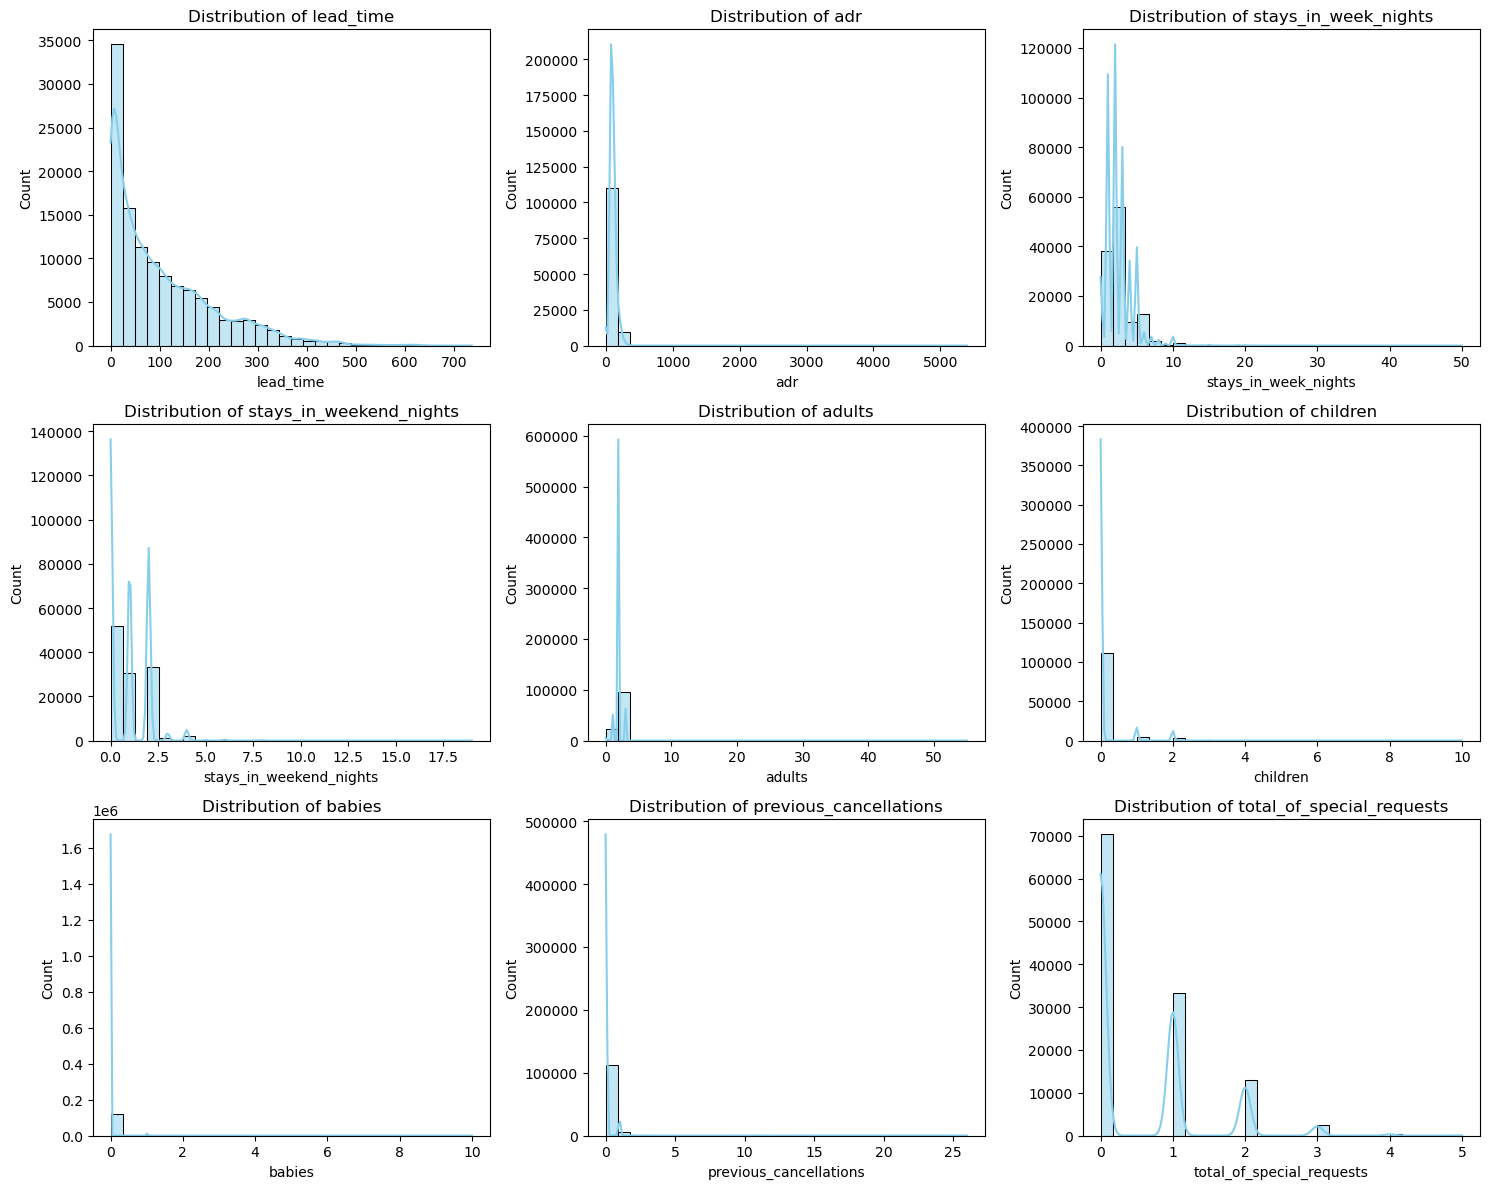

In [7]:
# Plot distribution of key numerical features
fig, axes = plt.subplots(3, 3, figsize=(15,12))
numeric_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'total_of_special_requests']
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

---

## 4. Data Preprocessing

---


In [9]:
#Define features and target variable
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

In [10]:
#Handling missing values
X.fillna({'children': 0, 'country': 'Unknown', 'agent':0, 'company':0}, inplace=True)

In [12]:
#Encode categorical variables and scaling numerical features
categorical_features = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
                        'distribution_channel', 'reserved_room_type', 'assigned_room_type',
                        'deposit_type', 'customer_type']
numeric_features = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'total_of_special_requests']

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('scaler', StandardScaler(), numeric_features)
])

In [13]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

---

## 5. Implementing AdaBoost

---

In [16]:
#Define AdaBoost model
adaboost_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                      n_estimators=100, random_state=42))
])


In [17]:
#Train the model
adaboost_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type']),
                                                 ('scaler', StandardScaler(),
                                                  ['lead_time', 'adr',
                                                   'stays_in_week_nights',
                                                   'stays_in_weekend_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'previous_cancellations',
                                                   'total_of_special_requests'])])),
                ('classifier',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                    n_estimators=100, random_state=42))])

In [18]:
#Predictions
y_pred_adaboost = adaboost_model.predict(X_test)

In [19]:
#Evaluation
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
print(f'AdaBoost Accuracy: {accuracy_adaboost:.2f}')
print(classification_report(y_test, y_pred_adaboost))

AdaBoost Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.80      0.91      0.85     14907
           1       0.81      0.63      0.71      8971

    accuracy                           0.81     23878
   macro avg       0.81      0.77      0.78     23878
weighted avg       0.81      0.81      0.80     23878



### 5.1 Feature Importance Visualization (AdaBoost)

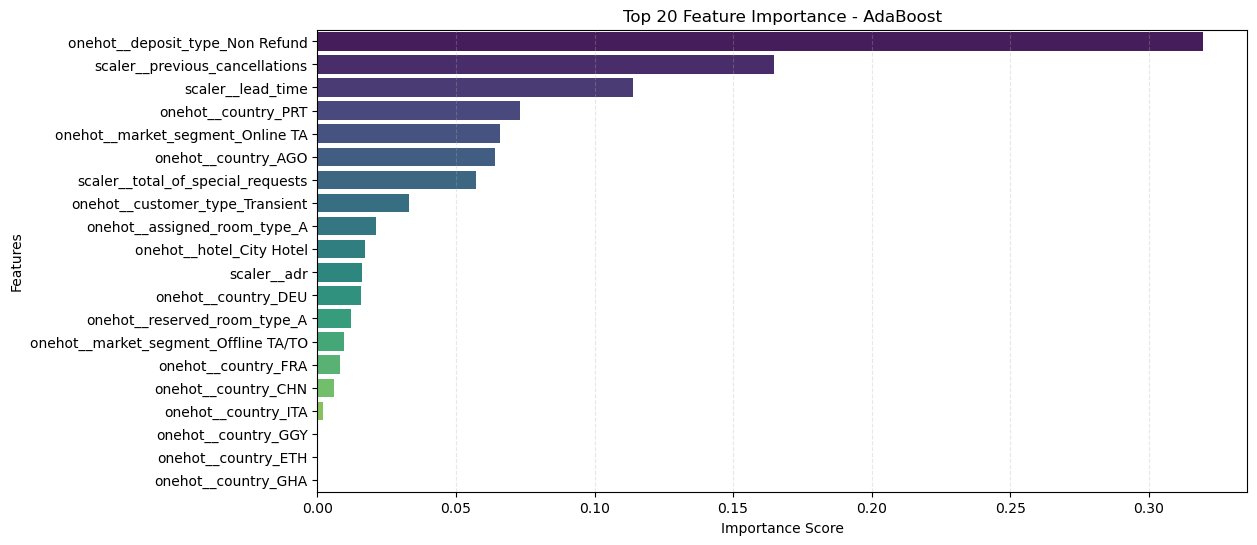

In [26]:
#get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

#Extract feature importances
feature_importance = adaboost_model.named_steps['classifier'].feature_importances_

#Sort feature by importance
sorted_idx = np.argsort(feature_importance)[::-1]

#Select top most important features
top_n = 20
top_features = np.array(feature_names)[sorted_idx][:top_n]
top_importance = feature_importance[sorted_idx][:top_n]

#plot feature importance
plt.figure(figsize=(12,6))
sns.barplot(x=top_importance, y=top_features, hue=top_features,palette='viridis', legend=False)
plt.title('Top 20 Feature Importance - AdaBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')

#Rotate y-axis
plt.yticks(rotation=0, fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

---

## 6. Implementing Gradient Boosting

---

In [28]:
#Define Gradient Boosting Model
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                              max_depth=3, random_state=42))
])

In [29]:
#Train the model
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type']),
                                                 ('scaler', StandardScaler(),
                                                  ['lead_time', 'adr',
                                                   'stays_in_week_nights',
                                                   'stays_in_weekend_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'previous_cancellations',
                                                   'total_of_special_requests'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [30]:
#predictions
y_pred_gb = gb_model.predict(X_test)

In [31]:
#Evaluation
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f'Gradient Boosting Accuracy: {accuracy_gb:.2f}')
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.83      0.91      0.87     14907
           1       0.83      0.70      0.76      8971

    accuracy                           0.83     23878
   macro avg       0.83      0.81      0.81     23878
weighted avg       0.83      0.83      0.83     23878



### 6.1 Feature Importance Visualization Gradient Boosting

---

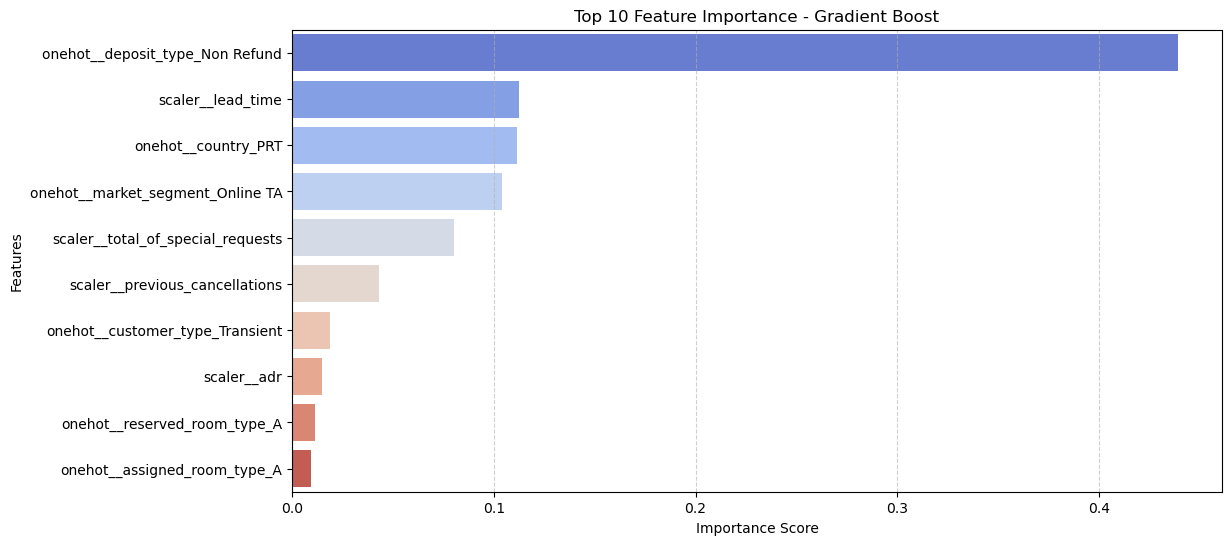

In [33]:
#Get feature names after preprocessing
feature_names_gb = preprocessor.get_feature_names_out()

#Extract feature importances
feature_importance_gb = gb_model.named_steps['classifier'].feature_importances_

#Sort features by importance
sorted_idx_gb = np.argsort(feature_importance_gb)[::-1]

#Select top 10 most important features
top_n_gb = 10
top_features_gb = np.array(feature_names_gb)[sorted_idx_gb][:top_n_gb]
top_importance_gb = feature_importance_gb[sorted_idx_gb][:top_n_gb]

#plot feature importance
plt.figure(figsize=(12,6))
sns.barplot(x=top_importance_gb, y=top_features_gb,hue=top_features_gb,palette='coolwarm', legend=False)
plt.title('Top 10 Feature Importance - Gradient Boost')
plt.xlabel('Importance Score')
plt.ylabel('Features')

#Rotate y-axis
plt.yticks(rotation=0, fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

---

## 7. Model Performance Comparison

---

### 7.1 Confusion Matrix

---

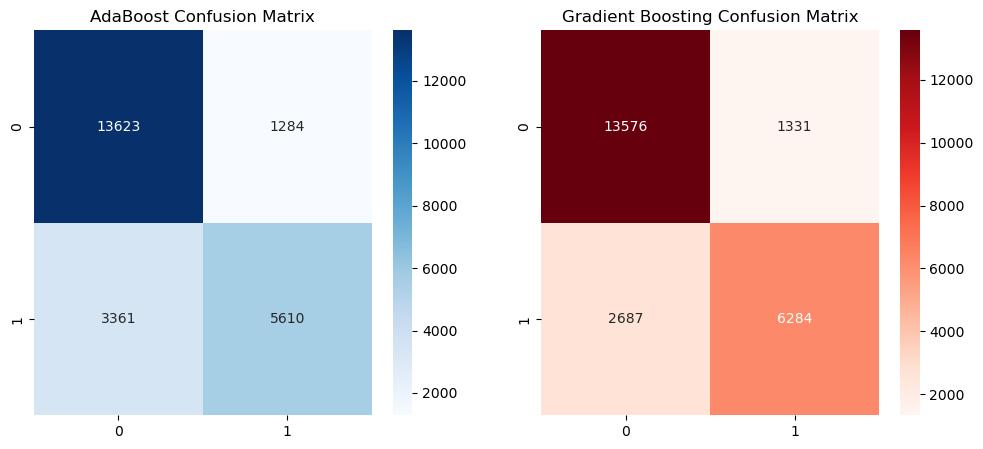

In [34]:
#Confusion Matrix AdaBoost
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_test, y_pred_adaboost), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('AdaBoost Confusion Matrix')

#Confusion Matrix Gradient Boost
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot = True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('Gradient Boosting Confusion Matrix')
plt.show()

### 7.2 ROC Curve

---

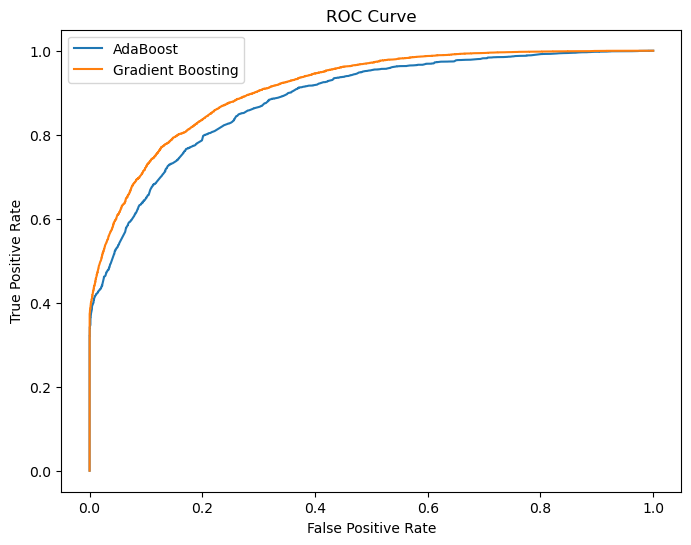

In [35]:
fpr_adaboost, tpr_adaboost, _ = roc_curve(y_test, adaboost_model.predict_proba(X_test)[:,1])
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8,6))
plt.plot(fpr_adaboost, tpr_adaboost, label='AdaBoost')
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()